## import all laibarery

In [7]:
# 🛠️ Advanced imports for production ML

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments

# 🧰 Sklearn libraries - expanded for advanced ML workflows
from sklearn.datasets import fetch_california_housing  # Real-world dataset
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment


In [9]:

class Config:
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # NEW: Validation set for tuning
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores
    
    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"
    
    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    
config = Config()

# Initialize MLflow for experiment tracking
mlflow.set_tracking_uri(
    f"file:///{os.path.abspath(config.EXPERIMENT_DIR).replace(os.sep, '/')}"
)
experiment_name = "Energy_Efficifncy"
mlflow.set_experiment(experiment_name)

2026/10/07 21:59:15 INFO mlflow.tracking.fluent: Experiment with name 'Energy_Efficifncy' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///c:/Users/admin/New '
 'folder/new-repo/1_Regression/sadeem_proj/experiments/974212155819418156'), creation_time=1791403155851, experiment_id='974212155819418156', last_update_time=1791403155851, lifecycle_stage='active', name='Energy_Efficifncy', tags={}>

## Loading Data and check it out

In [11]:
import pandas as  pd
df = pd.read_csv(r"C:\Users\admin\New folder\new-repo\1_Regression\sadeem_proj\New-repo\ENB2012_data.csv")
df.head()
df.shape
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
X7    0
X8    0
Y1    0
Y2    0
dtype: int64

## define the example and the target

In [12]:
df = df.drop(columns=['Y2'])
X = df[['X1','X2','X3','X4','X5','X6','X7','X8']]
Y = df['Y1']
print ("X shape : ", X.shape)
print ("Y shape : ", Y.shape)


X shape :  (768, 8)
Y shape :  (768,)


## Rename varibles and vislaued it

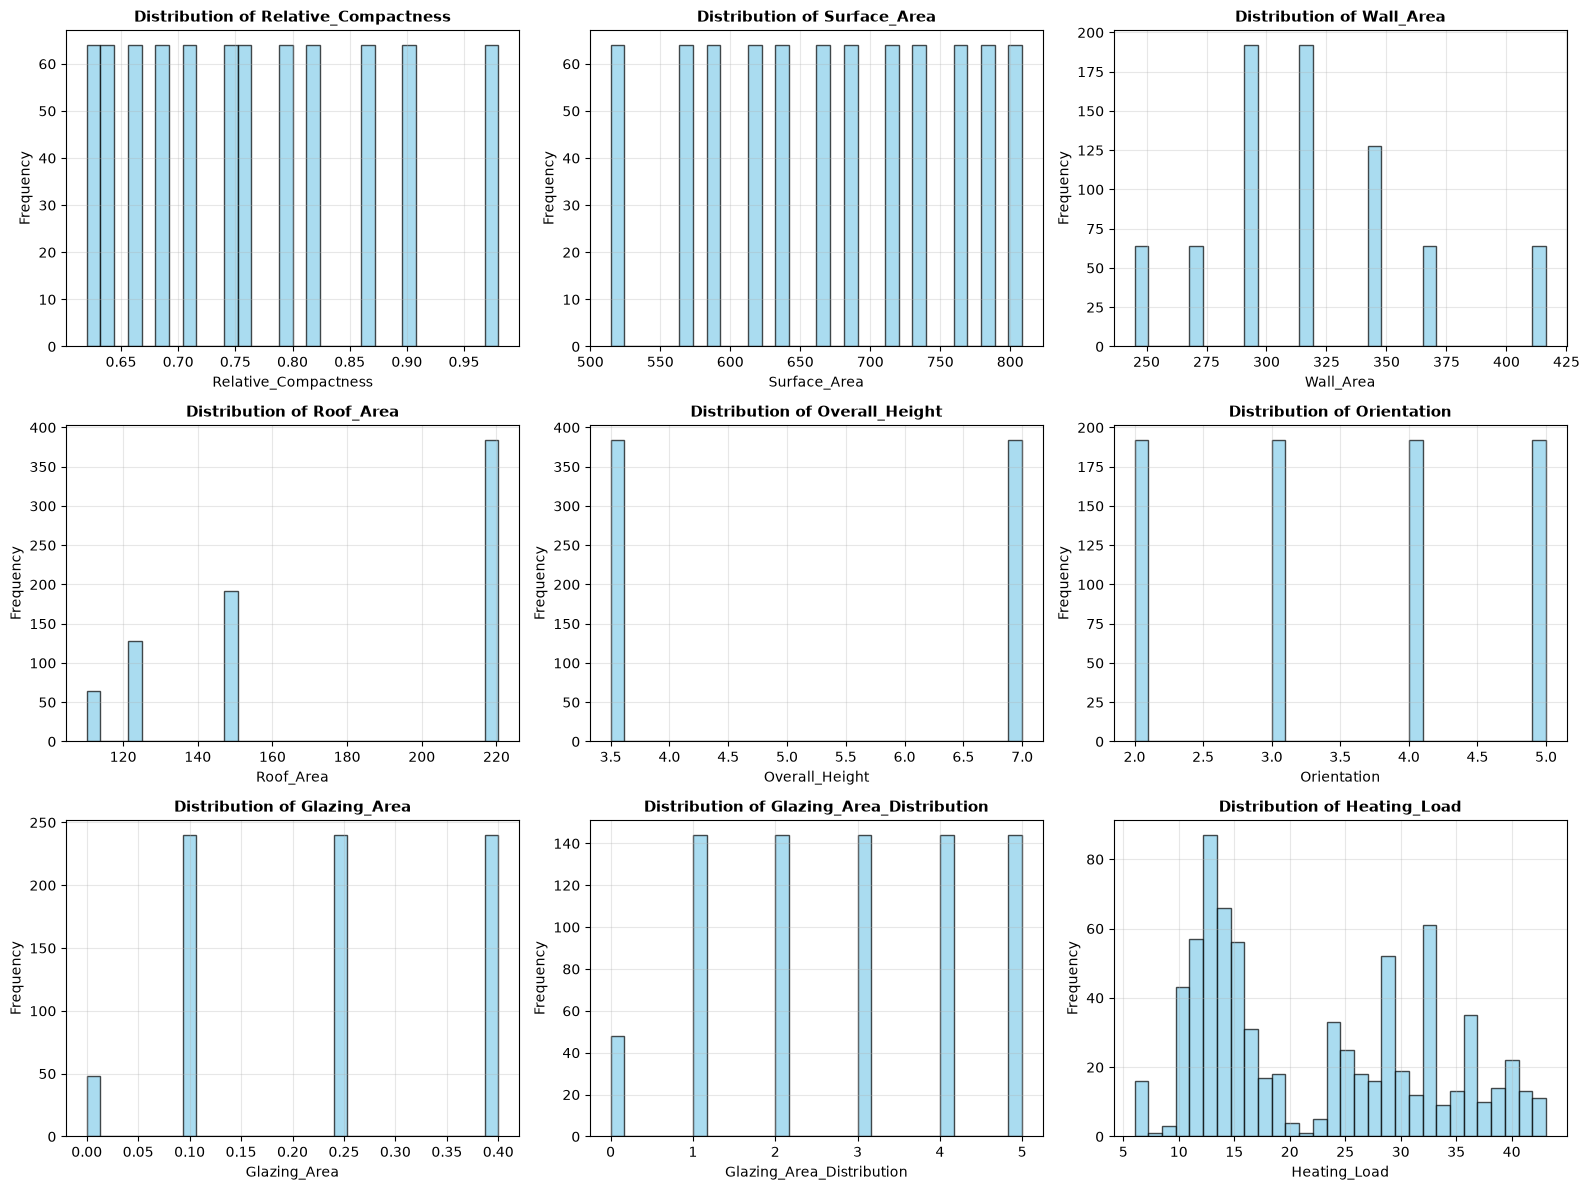

In [13]:
import matplotlib.pyplot as plt

column_names = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load'
}

df = df.rename(columns=column_names)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## correlation heatmap

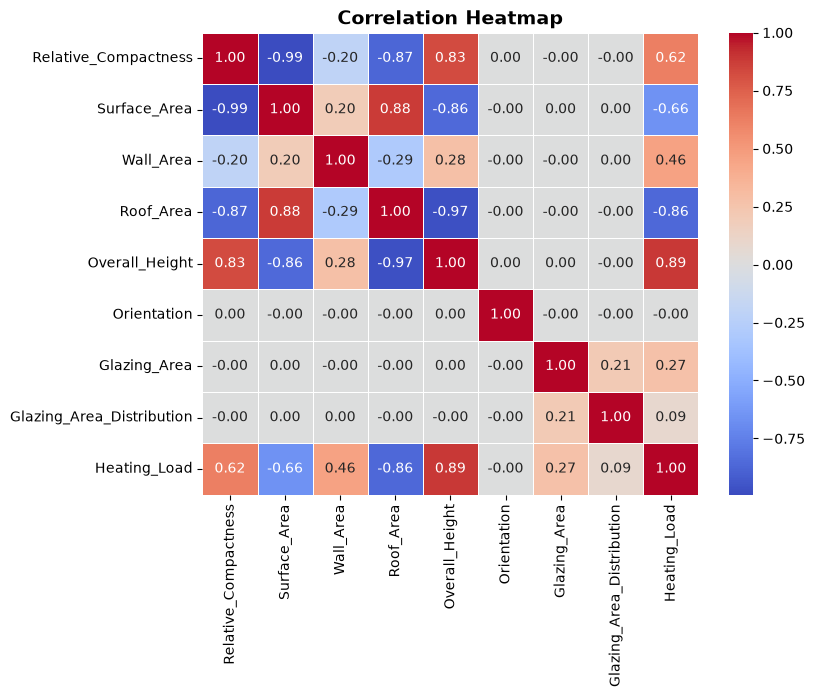

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()

EDA Note

Exploratory Data Analysis (EDA) was performed throughout the data preparation and visualization steps, including data inspection, statistical description, variable renaming, distribution plots, and correlation analysis.

## feature engineering

In [15]:
# Feature Engineering
df['Total_Surface_Area'] = df['Wall_Area'] + df['Roof_Area']
df['Height_to_Surface_Ratio'] = df['Overall_Height'] / df['Surface_Area']

# rerange
X = df.drop(columns=['Heating_Load'])
Y = df['Heating_Load']
print ("X shape : ", X.shape)
print ("Y shape : ", Y.shape)

X shape :  (768, 10)
Y shape :  (768,)


 ## checking the outliers

In [16]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((X < lower) | (X > upper)).sum()

print(outliers)

Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Total_Surface_Area           0
Height_to_Surface_Ratio      0
dtype: int64


## train-test split

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size= 0.2, random_state= 42)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 1_ Linear Regressin model :)

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)
Y_LR_pred = model.predict(X_test)

## 2_ Ridge model :)

In [21]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, Y_train)

ridge_train_pred = ridge_model.predict(X_train_scaled)
ridge_test_pred = ridge_model.predict(X_test_scaled)

## 3_ Elastic net model :)

In [22]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5)

elastic_model.fit(X_train_scaled, Y_train)

elastic_train_pred = elastic_model.predict(X_train_scaled)
elastic_test_pred = elastic_model.predict(X_test_scaled)

## 4_ polynomial model

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

polynomial_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

polynomial_model.fit(X_train, Y_train)

polynomial_train_pred = polynomial_model.predict(X_train)
polynomial_test_pred = polynomial_model.predict(X_test)

## 5_ gradient boosting

In [25]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gradient_model.fit(X_train, Y_train)

gradient_train_pred = gradient_model.predict(X_train)
gradient_test_pred = gradient_model.predict(X_test)

## 6_ SVR

In [26]:
from sklearn.svm import SVR

svr_model = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1
)

svr_model.fit(X_train_scaled, Y_train)

svr_train_pred = svr_model.predict(X_train_scaled)
svr_test_pred = svr_model.predict(X_test_scaled)

## 7_ Ensembl

In [27]:
from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, ElasticNet

ensemble_model = VotingRegressor([
    ("ridge", make_pipeline(StandardScaler(), Ridge(alpha=1.0))),
    ("elastic", make_pipeline(
        StandardScaler(),
        ElasticNet(alpha=1.0, l1_ratio=0.5)
    )),
    ("gradient", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

ensemble_model.fit(X_train, Y_train)

ensemble_train_pred = ensemble_model.predict(X_train)
ensemble_test_pred = ensemble_model.predict(X_test)

## 8_ random forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)


Y_pred_rf = rf_model.predict(X_test)


Random Forest R² Score: 0.9977
Random Forest MSE:      0.2401


## evaluation models

In [32]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

predictions = {
    "Linear Regression": Y_LR_pred,
    "Ridge": ridge_test_pred,
    "Elastic Net": elastic_test_pred,
    "Random Forest": Y_pred_rf,
    "Gradient Boosting": gradient_test_pred,
    "SVR": svr_test_pred,
    "Ensemble": ensemble_test_pred,
    "Polynomial Regression": polynomial_test_pred
}

results = []

for name, pred in predictions.items():
    r2 = r2_score(Y_test, pred)
    rmse = np.sqrt(mean_squared_error(Y_test, pred))
    mae = mean_absolute_error(Y_test, pred)

    results.append({
        "Model": name,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R²,RMSE,MAE
0,Random Forest,0.997697,0.489968,0.352933
1,Gradient Boosting,0.997495,0.511028,0.391120
2,SVR,0.996561,0.598735,0.448613
3,Polynomial Regression,0.993794,0.804248,0.604352
4,Ensemble,0.948445,2.318115,1.625537
5,Ridge,0.913304,3.006064,2.159691
6,Linear Regression,0.912187,3.025382,2.182010
7,Elastic Net,0.834158,4.157639,3.082312


## Hyperparameter Tuning for Best 3 models

In [33]:
# Hyperparameter Tuning for Best 3 Models

from sklearn.model_selection import GridSearchCV

# 1. Random Forest
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, Y_train)


# 2. Gradient Boosting
gb_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    gradient_model,
    gb_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, Y_train)


# 3. SVR
svr_param_grid = {
    "C": [10, 100],
    "epsilon": [0.01, 0.1],
    "gamma": ["scale", "auto"]
}

svr_grid = GridSearchCV(
    svr_model,
    svr_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

svr_grid.fit(X_train_scaled, Y_train)


# Best parameters
print("Random Forest Best Parameters:")
print(rf_grid.best_params_)

print("\nGradient Boosting Best Parameters:")
print(gb_grid.best_params_)

print("\nSVR Best Parameters:")
print(svr_grid.best_params_)

Random Forest Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Gradient Boosting Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

SVR Best Parameters:
{'C': 100, 'epsilon': 0.1, 'gamma': 'auto'}


In [35]:
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_
best_svr = svr_grid.best_estimator_

best_rf_pred = best_rf.predict(X_test)
best_gb_pred = best_gb.predict(X_test)
best_svr_pred = best_svr.predict(X_test_scaled)

## evaluation of tuned model

In [36]:
tuned_models = {
    "Tuned Random Forest": best_rf_pred,
    "Tuned Gradient Boosting": best_gb_pred,
    "Tuned SVR": best_svr_pred
}

tuned_results = []

for name, pred in tuned_models.items():
    r2 = r2_score(Y_test, pred)
    rmse = np.sqrt(mean_squared_error(Y_test, pred))
    mae = mean_absolute_error(Y_test, pred)

    tuned_results.append({
        "Model": name,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

,Model,R²,RMSE,MAE
0,Tuned Gradient Boosting,0.998032,0.452940,0.350228
1,Tuned Random Forest,0.997697,0.489968,0.352933
2,Tuned SVR,0.996561,0.598735,0.448613


In [37]:
final_results = pd.concat(
    [results_df, tuned_results_df],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

final_results

,Model,R²,RMSE,MAE
0,Tuned Gradient Boosting,0.998032,0.452940,0.350228
1,Tuned Random Forest,0.997697,0.489968,0.352933
2,Random Forest,0.997697,0.489968,0.352933
3,Gradient Boosting,0.997495,0.511028,0.391120
4,SVR,0.996561,0.598735,0.448613
5,Tuned SVR,0.996561,0.598735,0.448613
6,Polynomial Regression,0.993794,0.804248,0.604352
7,Ensemble,0.948445,2.318115,1.625537
8,Ridge,0.913304,3.006064,2.159691
9,Linear Regression,0.912187,3.025382,2.182010


## model card and joblib

In [38]:
import joblib
import json

# Save the final model and scaler
joblib.dump(best_gb, "energy_model.joblib")
joblib.dump(scaler, "scaler.joblib")

# Get the final model metrics
final_metrics = tuned_results_df[
    tuned_results_df["Model"] == "Tuned Gradient Boosting"
].iloc[0]

# Create Model Card
model_card = {
    "model_type": "GradientBoostingRegressor",
    "tuning": "GridSearchCV",
    "r2_score": float(final_metrics["R²"]),
    "rmse": float(final_metrics["RMSE"]),
    "mae": float(final_metrics["MAE"]),
    "features": list(X.columns),
    "target": "Heating_Load"
}

with open("model_card.json", "w") as f:
    json.dump(model_card, f, indent=4)

In [39]:
with mlflow.start_run(run_name="Tuned_Gradient_Boosting_Final"):

    mlflow.log_params(best_gb.get_params())

    mlflow.log_metric("R2", float(final_metrics["R²"]))
    mlflow.log_metric("RMSE", float(final_metrics["RMSE"]))
    mlflow.log_metric("MAE", float(final_metrics["MAE"]))

    mlflow.sklearn.log_model(
        best_gb,
        "final_model"
    )

print("Final model logged to MLflow successfully.")

2026/10/08 13:37:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/08 13:38:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Final model logged to MLflow successfully.


In [40]:
X.columns.tolist()

['Relative_Compactness',
 'Surface_Area',
 'Wall_Area',
 'Roof_Area',
 'Overall_Height',
 'Orientation',
 'Glazing_Area',
 'Glazing_Area_Distribution',
 'Total_Surface_Area',
 'Height_to_Surface_Ratio']

In [42]:
final_metrics

Model    Tuned Gradient Boosting
R²                      0.998032
RMSE                     0.45294
MAE                     0.350228
Name: 1, dtype: object